# Polynomial Regression with Gradient Descent — Concept Notes

Fitting a noisy sine wave with linear and polynomial models.

---

## 1. The Problem

We observe samples from a **sine wave corrupted by Gaussian noise**:

$$
y_i = \sin(x_i) + \varepsilon_i, \qquad
\varepsilon_i \sim \mathcal{N}(0, \sigma^2), \qquad
x_i \in [-\pi, \pi]
$$

Goal: recover the underlying curve. We compare:

- **Linear regression**: $\hat{y} = w x + b$
- **Polynomial regression of degree $d$**: $\hat{y} = \sum_{k=0}^{d} w_k x^k$

Both are trained by minimizing the Mean Squared Error (MSE) with
gradient descent.

---

## 2. The Gradient Descent Idea

Given a differentiable loss $J(\mathbf{w})$, repeatedly move parameters
opposite to the gradient:

$$
\mathbf{w} \leftarrow \mathbf{w} - \alpha \, \nabla_{\mathbf{w}} J(\mathbf{w})
$$

For small enough $\alpha$, the first-order Taylor expansion guarantees
descent:

$$
J\bigl(\mathbf{w} - \alpha \nabla_{\mathbf{w}} J\bigr)
\approx J(\mathbf{w}) - \alpha \, \|\nabla_{\mathbf{w}} J\|_2^2
< J(\mathbf{w})
$$

provided $\nabla_{\mathbf{w}} J \neq \mathbf{0}$.

---

## 3. Loss and Gradient — Linear Regression

**Model:**

$$
\hat{y}_i = w x_i + b
$$

**Loss (MSE):**

$$
J(w, b) = \frac{1}{N} \sum_{i=1}^{N} \bigl( w x_i + b - y_i \bigr)^2
$$

**Gradients:**

$$
\frac{\partial J}{\partial w}
= \frac{2}{N} \sum_{i=1}^{N} x_i \bigl( w x_i + b - y_i \bigr)
$$

$$
\frac{\partial J}{\partial b}
= \frac{2}{N} \sum_{i=1}^{N} \bigl( w x_i + b - y_i \bigr)
$$

**Update rule:**

$$
w \leftarrow w - \alpha \frac{\partial J}{\partial w}, \qquad
b \leftarrow b - \alpha \frac{\partial J}{\partial b}
$$

---

## 4. Loss and Gradient — Polynomial Regression

**Model (degree $d$):**

$$
\hat{y}_i = \sum_{k=0}^{d} w_k \, x_i^{k}
$$

**Loss (MSE):**

$$
J(\mathbf{w}) = \frac{1}{N} \sum_{i=1}^{N}
\Bigl( \sum_{k=0}^{d} w_k \, x_i^{k} - y_i \Bigr)^{2}
$$

**Gradient w.r.t. each coefficient $w_j$:**

$$
\frac{\partial J}{\partial w_j}
= \frac{2}{N} \sum_{i=1}^{N}
\Bigl( \sum_{k=0}^{d} w_k \, x_i^{k} - y_i \Bigr) \, x_i^{\,j},
\qquad j = 0, 1, \dots, d
$$

**Matrix form.** With the **Vandermonde matrix**
$\mathbf{X} \in \mathbb{R}^{N \times (d+1)}$, $X_{ij} = x_i^{\,j}$:

$$
J(\mathbf{w}) = \frac{1}{N} \bigl\| \mathbf{X}\mathbf{w} - \mathbf{y} \bigr\|_2^{2}
$$

$$
\nabla_{\mathbf{w}} J
= \frac{2}{N} \mathbf{X}^{\top} \bigl( \mathbf{X}\mathbf{w} - \mathbf{y} \bigr)
$$

**Update rule:**

$$
\mathbf{w} \leftarrow \mathbf{w} - \alpha \, \nabla_{\mathbf{w}} J
$$

Setting $d = 1$ and $x^0 = 1$ recovers linear regression exactly.

---

## 5. Ridge-Regularized Polynomial Regression

For high degrees, coefficients grow large and the model overfits. Add an
$L_2$ penalty:

$$
J_{\text{ridge}}(\mathbf{w})
= \frac{1}{N} \bigl\| \mathbf{X}\mathbf{w} - \mathbf{y} \bigr\|_2^{2}
+ \lambda \, \|\mathbf{w}\|_2^{2}
$$

**Gradient:**

$$
\nabla_{\mathbf{w}} J_{\text{ridge}}
= \frac{2}{N} \mathbf{X}^{\top} (\mathbf{X}\mathbf{w} - \mathbf{y})
+ 2 \lambda \, \mathbf{w}
$$

---

## 6. Why SGD? — The Idea

### Batch Gradient Descent

Uses **all $N$ samples** per update:

$$
\nabla_{\mathbf{w}} J
= \frac{2}{N} \sum_{i=1}^{N}
\bigl( \mathbf{x}_i^{\top}\mathbf{w} - y_i \bigr) \mathbf{x}_i
$$

Cost per update: $\mathcal{O}(N d)$. Smooth but slow when $N$ is large.

### Stochastic Gradient Descent (SGD)

Uses **one sample** per update:

$$
\nabla_{\mathbf{w}} J_i
= 2 \bigl( \mathbf{x}_i^{\top}\mathbf{w} - y_i \bigr) \mathbf{x}_i
$$

Cost per update: $\mathcal{O}(d)$. The estimate is **noisy** but
**unbiased**:

$$
\mathbb{E}_i\bigl[ \nabla_{\mathbf{w}} J_i \bigr]
= \nabla_{\mathbf{w}} J
$$

**Why it helps:**

1. **Speed** — many cheap updates per pass through the data.
2. **Noise as exploration** — random updates can escape shallow local
   minima and saddle points that trap batch GD.
3. **Online learning** — new data is incorporated immediately.
4. **Memory** — never need the whole dataset in memory at once.

**Practical requirements:**

- **Shuffle** the data every epoch.
- **Decay** the learning rate over time, e.g.
  $\alpha_t = \alpha_0 / (1 + t \tau)$.

### Mini-Batch Gradient Descent

Compromise: use a batch $B$ of size $b$ (16, 32, 64, 128, ...):

$$
\nabla_{\mathbf{w}} J_B
= \frac{2}{b} \sum_{i \in B}
\bigl( \mathbf{x}_i^{\top}\mathbf{w} - y_i \bigr) \mathbf{x}_i
$$

This is the **default in deep learning** (PyTorch `DataLoader`,
TensorFlow `tf.data`).

| Method | Samples / update | Gradient variance | Cost / update |
|---|---|---|---|
| Batch GD | $N$ | None | $\mathcal{O}(N d)$ |
| SGD | $1$ | High | $\mathcal{O}(d)$ |
| Mini-batch | $b$ | Medium | $\mathcal{O}(b d)$ |

---

## 7. Feature Scaling

Raw powers $x^k$ for $x \in [-\pi, \pi]$ and $k = 5$ reach
$\pi^5 \approx 306$, while $x^0 = 1$. This imbalance makes the problem
ill-conditioned. Standardize first:

$$
x_{\text{std}} = \frac{x - \mu_x}{\sigma_x}
$$

where $\mu_x$ and $\sigma_x$ are the sample mean and standard deviation.

---

## 8. Summary of All Formulas

| Model | Loss $J$ | Gradient $\nabla_{\mathbf{w}} J$ |
|---|---|---|
| Linear | $\frac{1}{N}\sum_i (w x_i + b - y_i)^2$ | $\frac{2}{N}\sum_i (w x_i + b - y_i)(x_i, 1)^{\top}$ |
| Polynomial | $\frac{1}{N}\|\mathbf{X}\mathbf{w} - \mathbf{y}\|_2^2$ | $\frac{2}{N}\mathbf{X}^{\top}(\mathbf{X}\mathbf{w} - \mathbf{y})$ |
| Ridge | $\frac{1}{N}\|\mathbf{X}\mathbf{w} - \mathbf{y}\|_2^2 + \lambda\|\mathbf{w}\|_2^2$ | $\frac{2}{N}\mathbf{X}^{\top}(\mathbf{X}\mathbf{w} - \mathbf{y}) + 2\lambda\mathbf{w}$ |

**Universal update:**

$$
\boxed{\; \mathbf{w} \leftarrow \mathbf{w} - \alpha \, \nabla_{\mathbf{w}} J \;}
$$

Training Batch GD (linear, degree 1)...
Training Batch GD (polynomial, degree 5)...
Training SGD (polynomial, degree 5)...
Training Mini-Batch GD (polynomial, degree 5)...

  Linear (Batch GD)      final MSE = 0.29336
  Poly-5 (Batch GD)      final MSE = nan
  Poly-5 (SGD)           final MSE = 0.66256
  Poly-5 (Mini-batch)    final MSE = nan


/var/folders/k1/8851q1nj2j3dnxw7hpy7f4f80000gn/T/ipykernel_89642/1936798021.py:63: RuntimeWarning: overflow encountered in square
  loss = float(np.mean(err ** 2))
/var/folders/k1/8851q1nj2j3dnxw7hpy7f4f80000gn/T/ipykernel_89642/1936798021.py:61: RuntimeWarning: overflow encountered in matmul
  grad = (2.0 / N) * (Xmat.T @ err)
/var/folders/k1/8851q1nj2j3dnxw7hpy7f4f80000gn/T/ipykernel_89642/1936798021.py:61: RuntimeWarning: invalid value encountered in matmul
  grad = (2.0 / N) * (Xmat.T @ err)
/var/folders/k1/8851q1nj2j3dnxw7hpy7f4f80000gn/T/ipykernel_89642/1936798021.py:62: RuntimeWarning: invalid value encountered in subtract
  w -= lr * grad
/var/folders/k1/8851q1nj2j3dnxw7hpy7f4f80000gn/T/ipykernel_89642/1936798021.py:43: RuntimeWarning: overflow encountered in square
  return float(np.mean((y_pred - y) ** 2))
/var/folders/k1/8851q1nj2j3dnxw7hpy7f4f80000gn/T/ipykernel_89642/1936798021.py:110: RuntimeWarning: overflow encountered in matmul
  grad = (2.0 / len(b)) * (Xb.T @ err)
/v

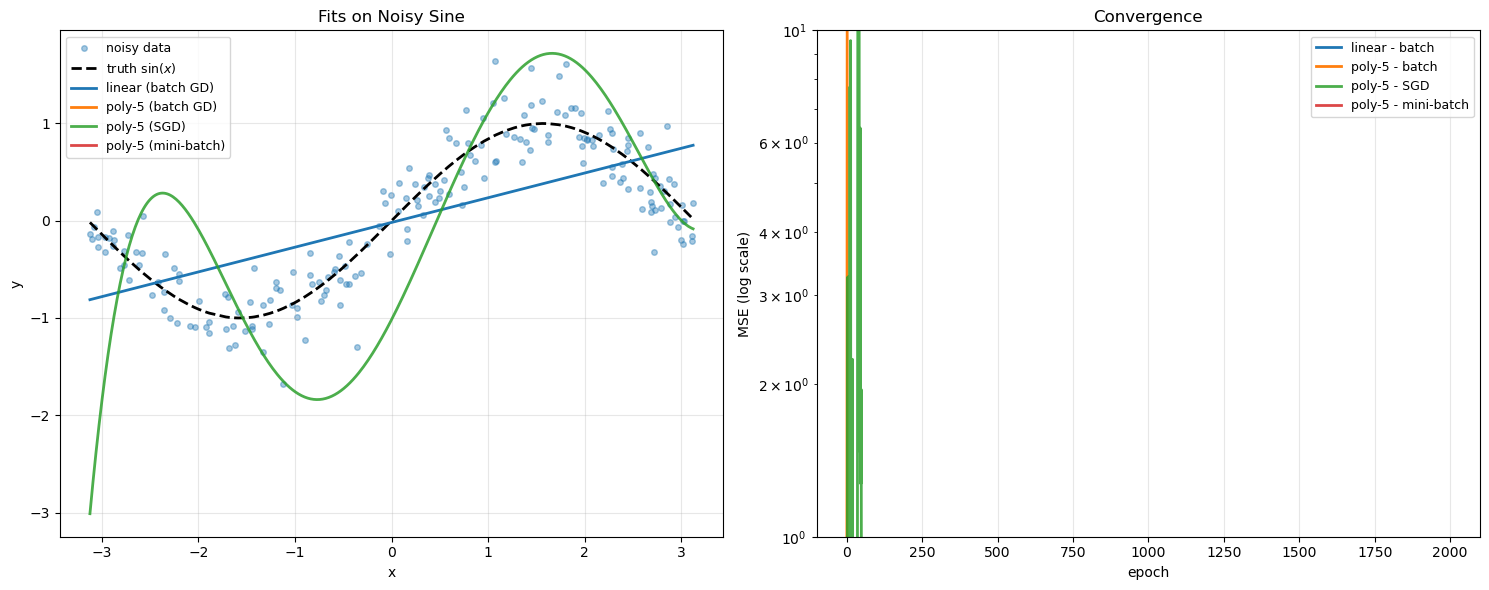

/var/folders/k1/8851q1nj2j3dnxw7hpy7f4f80000gn/T/ipykernel_89642/1936798021.py:60: RuntimeWarning: invalid value encountered in matmul
  err = Xmat @ w - y
/var/folders/k1/8851q1nj2j3dnxw7hpy7f4f80000gn/T/ipykernel_89642/1936798021.py:134: RuntimeWarning: overflow encountered in square
  losses.append(float(np.mean(err ** 2)))
/var/folders/k1/8851q1nj2j3dnxw7hpy7f4f80000gn/T/ipykernel_89642/1936798021.py:132: RuntimeWarning: overflow encountered in matmul
  grad = (2.0 / N) * (Xmat.T @ err) + 2.0 * lam * w
/var/folders/k1/8851q1nj2j3dnxw7hpy7f4f80000gn/T/ipykernel_89642/1936798021.py:131: RuntimeWarning: invalid value encountered in matmul
  err = Xmat @ w - y


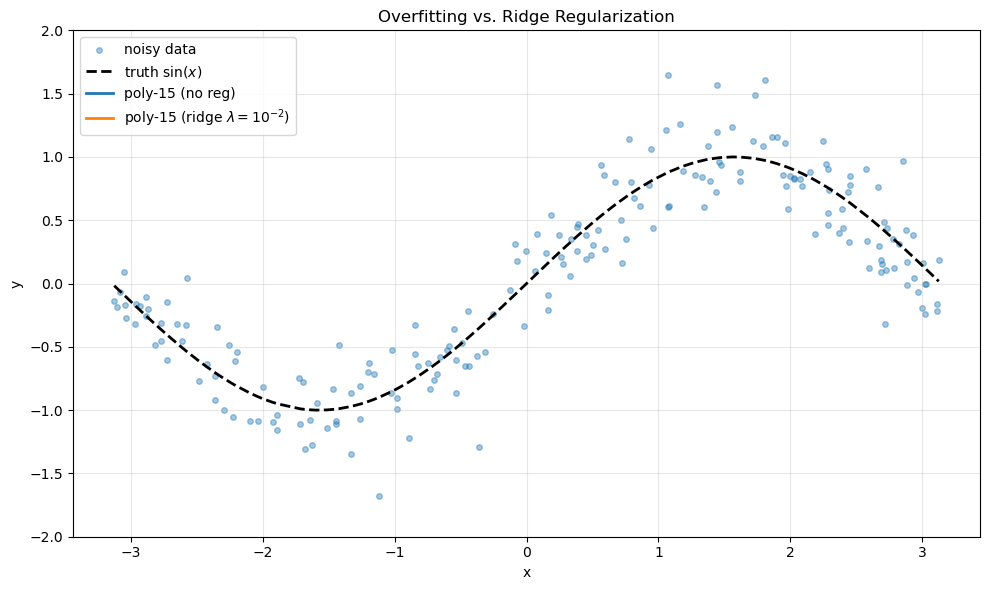


Saved: polynomial_regression_results.png
Saved: polynomial_regression_overfitting.png


In [11]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


# =============================================================================
# 1. SYNTHETIC DATA — SINE WAVE + GAUSSIAN NOISE
# =============================================================================
def generate_data(N=200, sigma=0.25, seed=0):
    r"""Return x in [-pi, pi] and y = sin(x) + N(0, sigma^2)."""
    rng = np.random.default_rng(seed)
    X = rng.uniform(-np.pi, np.pi, size=N)
    y = np.sin(X) + rng.normal(0, sigma, size=N)
    return X, y


# =============================================================================
# 2. HELPERS
# =============================================================================
def standardize(x):
    r"""Zero-mean, unit-variance transform:
    x_std = (x - mu_x) / sigma_x.  Return (x_std, mu, sd)."""
    mu, sd = x.mean(), x.std()
    return (x - mu) / sd, mu, sd


def vandermonde(x, degree):
    r"""Return [N, degree+1] Vandermonde matrix with columns x^0, ..., x^degree."""
    return np.vstack([x ** k for k in range(degree + 1)]).T


def predict(Xmat, w):
    r"""Linear prediction: y_hat = X w."""
    return Xmat @ w


def mse(y_pred, y):
    r"""Mean squared error: (1/N) * sum_i (y_hat_i - y_i)^2."""
    return float(np.mean((y_pred - y) ** 2))


# =============================================================================
# 3. OPTIMIZERS
# =============================================================================
def batch_gd(Xmat, y, lr=0.1, epochs=2000, verbose=False):
    r"""Batch gradient descent.

    Update:
        grad_w J = (2/N) * X^T ( X w - y )
        w <- w - alpha * grad_w J
    """
    N, D = Xmat.shape
    w = np.zeros(D)
    losses = []
    for epoch in range(epochs):
        err = Xmat @ w - y
        grad = (2.0 / N) * (Xmat.T @ err)
        w -= lr * grad
        loss = float(np.mean(err ** 2))
        losses.append(loss)
        if verbose and (epoch + 1) % max(1, epochs // 10) == 0:
            print(f"  [batch] epoch {epoch+1:5d}  loss = {loss:.6f}")
    return w, losses


def sgd(Xmat, y, lr=0.005, epochs=50, verbose=False):
    r"""Stochastic gradient descent (one sample per update).

    Per-sample update:
        grad_w J_i = 2 * ( x_i^T w - y_i ) * x_i
        w <- w - alpha * grad_w J_i
    """
    N, D = Xmat.shape
    w = np.zeros(D)
    losses = []
    rng = np.random.default_rng(42)
    for epoch in range(epochs):
        for i in rng.permutation(N):
            xi = Xmat[i]
            err = xi @ w - y[i]
            w -= lr * 2.0 * err * xi
        loss = mse(Xmat @ w, y)
        losses.append(loss)
        if verbose and (epoch + 1) % max(1, epochs // 10) == 0:
            print(f"  [sgd]   epoch {epoch+1:5d}  loss = {loss:.6f}")
    return w, losses


def minibatch_gd(Xmat, y, lr=0.05, epochs=200, batch_size=16, verbose=False):
    r"""Mini-batch gradient descent.

    Batch update (batch B of size b):
        grad_w J_B = (2/b) * X_B^T ( X_B w - y_B )
        w <- w - alpha * grad_w J_B
    """
    N, D = Xmat.shape
    w = np.zeros(D)
    losses = []
    rng = np.random.default_rng(7)
    for epoch in range(epochs):
        idx = rng.permutation(N)
        for s in range(0, N, batch_size):
            b = idx[s:s + batch_size]
            Xb, yb = Xmat[b], y[b]
            err = Xb @ w - yb
            grad = (2.0 / len(b)) * (Xb.T @ err)
            w -= lr * grad
        loss = mse(Xmat @ w, y)
        losses.append(loss)
        if verbose and (epoch + 1) % max(1, epochs // 10) == 0:
            print(f"  [mini]  epoch {epoch+1:5d}  loss = {loss:.6f}")
    return w, losses


def batch_gd_ridge(Xmat, y, lr=0.1, epochs=2000, lam=1e-2):
    r"""Batch GD with L2 penalty.

    Loss:
        J_ridge(w) = (1/N) || X w - y ||_2^2 + lambda || w ||_2^2
    Gradient:
        grad_w J_ridge = (2/N) X^T ( X w - y ) + 2 lambda w
    """
    N, D = Xmat.shape
    w = np.zeros(D)
    losses = []
    for _ in range(epochs):
        err = Xmat @ w - y
        grad = (2.0 / N) * (Xmat.T @ err) + 2.0 * lam * w
        w -= lr * grad
        losses.append(float(np.mean(err ** 2)))
    return w, losses


# =============================================================================
# 4. MAIN EXPERIMENT
# =============================================================================
def main():
    # ---- Data ----
    N = 200
    sigma = 0.25
    X, y = generate_data(N=N, sigma=sigma, seed=0)

    order = np.argsort(X)
    Xs, ys_true = X[order], np.sin(X[order])

    # ---- Standardize x, build Vandermonde matrices ----
    X_std, mu, sd = standardize(X)

    deg_poly = 5
    Xlin = vandermonde(X_std, 1)          # [N, 2]
    Xpoly = vandermonde(X_std, deg_poly)  # [N, 6]

    # ---- Train ----
    print("Training Batch GD (linear, degree 1)...")
    w_lin_gd, losses_lin_gd = batch_gd(Xlin, y, lr=0.1, epochs=2000)

    print("Training Batch GD (polynomial, degree 5)...")
    w_poly_gd, losses_poly_gd = batch_gd(Xpoly, y, lr=0.1, epochs=2000)

    print("Training SGD (polynomial, degree 5)...")
    w_poly_sgd, losses_poly_sgd = sgd(Xpoly, y, lr=0.005, epochs=50)

    print("Training Mini-Batch GD (polynomial, degree 5)...")
    w_poly_mb, losses_poly_mb = minibatch_gd(
        Xpoly, y, lr=0.05, epochs=200, batch_size=16
    )

    print()
    print(f"  Linear (Batch GD)      final MSE = {losses_lin_gd[-1]:.5f}")
    print(f"  Poly-5 (Batch GD)      final MSE = {losses_poly_gd[-1]:.5f}")
    print(f"  Poly-5 (SGD)           final MSE = {losses_poly_sgd[-1]:.5f}")
    print(f"  Poly-5 (Mini-batch)    final MSE = {losses_poly_mb[-1]:.5f}")

    # ---- Predictions on a dense grid ----
    x_grid = np.linspace(X.min(), X.max(), 400)
    x_grid_std = (x_grid - mu) / sd
    Xg_lin = vandermonde(x_grid_std, 1)
    Xg_poly = vandermonde(x_grid_std, deg_poly)

    y_lin_gd = Xg_lin @ w_lin_gd
    y_poly_gd = Xg_poly @ w_poly_gd
    y_poly_sgd = Xg_poly @ w_poly_sgd
    y_poly_mb = Xg_poly @ w_poly_mb

    # ---- Figure 1: fits + loss curves ----
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    ax = axes[0]
    ax.scatter(X, y, s=16, alpha=0.4, label="noisy data")
    ax.plot(Xs, ys_true, "k--", lw=2, label=r"truth $\sin(x)$")
    ax.plot(x_grid, y_lin_gd, lw=2, label="linear (batch GD)")
    ax.plot(x_grid, y_poly_gd, lw=2, label="poly-5 (batch GD)")
    ax.plot(x_grid, y_poly_sgd, lw=2, alpha=0.85, label="poly-5 (SGD)")
    ax.plot(x_grid, y_poly_mb, lw=2, alpha=0.85, label="poly-5 (mini-batch)")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Fits on Noisy Sine")
    ax.legend(fontsize=9)

    ax = axes[1]
    ax.plot(losses_lin_gd, lw=2, label="linear - batch")
    ax.plot(losses_poly_gd, lw=2, label="poly-5 - batch")
    ax.plot(losses_poly_sgd, lw=2, alpha=0.85, label="poly-5 - SGD")
    ax.plot(losses_poly_mb, lw=2, alpha=0.85, label="poly-5 - mini-batch")
    ax.set_yscale("log")
    ax.set_xlabel("epoch")
    ax.set_ylabel("MSE (log scale)")
    ax.set_title("Convergence")
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig("polynomial_regression_results.png", dpi=130)
    plt.show()

    # ---- Figure 2: overfitting vs ridge regularization (degree 15) ----
    deg = 15
    Xhigh = vandermonde(X_std, deg)
    w_hi_plain, _ = batch_gd(Xhigh, y, lr=0.05, epochs=3000)
    w_hi_ridge, _ = batch_gd_ridge(Xhigh, y, lr=0.05, epochs=3000, lam=1e-2)

    Xg_high = vandermonde(x_grid_std, deg)
    y_hi_plain = Xg_high @ w_hi_plain
    y_hi_ridge = Xg_high @ w_hi_ridge

    plt.figure()
    plt.scatter(X, y, s=16, alpha=0.4, label="noisy data")
    plt.plot(Xs, ys_true, "k--", lw=2, label=r"truth $\sin(x)$")
    plt.plot(x_grid, y_hi_plain, lw=2, label="poly-15 (no reg)")
    plt.plot(x_grid, y_hi_ridge, lw=2,
             label=r"poly-15 (ridge $\lambda=10^{-2}$)")
    plt.ylim(-2, 2)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Overfitting vs. Ridge Regularization")
    plt.legend()
    plt.tight_layout()
    plt.savefig("polynomial_regression_overfitting.png", dpi=130)
    plt.show()

    print()
    print("Saved: polynomial_regression_results.png")
    print("Saved: polynomial_regression_overfitting.png")


if __name__ == "__main__":
    main()